In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, classification_report)

# Machine Learning Algorithms
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Explainable AI
import shap

# Configuration
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

In [43]:
# Load dataset
df = pd.read_csv("startup data.csv")

# Quick Inspection
print(f"Dataset Shape: {df.shape}")
print("\nTarget Variable Breakdown:")
print(df['status'].value_counts())
df.head()

Dataset Shape: (923, 49)

Target Variable Breakdown:
status
acquired    597
closed      326
Name: count, dtype: int64


,Unnamed: 0,state_code,latitude,longitude,zip_code,id,city,Unnamed: 6,name,labels,...,object_id,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500,status
0,1005,CA,42.358880,-71.056820,92101,c:6669,San Diego,NaN,Bandsintown,1,...,c:6669,0,1,0,0,0,0,1.0000,0,acquired
1,204,CA,37.238916,-121.973718,95032,c:16283,Los Gatos,NaN,TriCipher,1,...,c:16283,1,0,0,1,1,1,4.7500,1,acquired
2,1001,CA,32.901049,-117.192656,92121,c:65620,San Diego,San Diego CA 92121,Plixi,1,...,c:65620,0,0,1,0,0,0,4.0000,1,acquired
3,738,CA,37.320309,-122.050040,95014,c:42668,Cupertino,Cupertino CA 95014,Solidcore Systems,1,...,c:42668,0,0,0,1,1,1,3.3333,1,acquired
4,1002,CA,37.779281,-122.419236,94105,c:65806,San Francisco,San Francisco CA 94105,Inhale Digital,0,...,c:65806,1,1,0,0,0,0,1.0000,1,closed


In [44]:
# Drop unique identifiers, redundant features, and alternative target columns
# Create a safe list of columns to drop that does NOT include your target
# We will drop 'Closed' but KEEP 'labels' or 'status' as the target vector
drop_cols = ['Unnamed: 0', 'id', 'object_id', 'name', 'state_code.1', 'Closed']

df_cleaned = df.drop(columns=[col for col in drop_cols if col in df.columns])

print("Columns currently available in df_cleaned:")
print(list(df_cleaned.columns))
print(f"Cleaned Dataset Shape (After dropping leakage columns): {df_cleaned.shape}")

Columns currently available in df_cleaned:
['state_code', 'latitude', 'longitude', 'zip_code', 'city', 'Unnamed: 6', 'labels', 'founded_at', 'closed_at', 'first_funding_at', 'last_funding_at', 'age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year', 'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones', 'is_CA', 'is_NY', 'is_MA', 'is_TX', 'is_otherstate', 'category_code', 'is_software', 'is_web', 'is_mobile', 'is_enterprise', 'is_advertising', 'is_gamesvideo', 'is_ecommerce', 'is_biotech', 'is_consulting', 'is_othercategory', 'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'has_roundD', 'avg_participants', 'is_top500', 'status']
Cleaned Dataset Shape (After dropping leakage columns): (923, 44)


In [45]:
# Convert date strings to datetime objects safely
date_features = ['founded_at', 'closed_at', 'first_funding_at', 'last_funding_at']
for col in date_features:
    if col in df_cleaned.columns:
        df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')

# Calculate highly predictive operational time deltas (in days)
df_cleaned['funding_duration_days'] = (df_cleaned['last_funding_at'] - df_cleaned['first_funding_at']).dt.days.fillna(0)
df_cleaned['age_at_first_funding_days'] = (df_cleaned['first_funding_at'] - df_cleaned['founded_at']).dt.days.fillna(0)

# Now drop the original raw datetime columns since we extracted their value
df_cleaned = df_cleaned.drop(columns=[col for col in date_features if col in df_cleaned.columns])

print("Feature Engineering complete. New columns added: 'funding_duration_days', 'age_at_first_funding_days'")

Feature Engineering complete. New columns added: 'funding_duration_days', 'age_at_first_funding_days'


In [46]:
# Import the missing scikit-learn modules explicitly inside this cell
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
possible_targets = ['labels', 'status', 'is_acquired', 'Is_Acquired']
target_col = None

for col in possible_targets:
    if col in df_cleaned.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError(f"Could not find the target column. Your available columns are: {list(df_cleaned.columns)}")

print(f"Detected target column: '{target_col}'")

X = df_cleaned.drop(columns=[target_col])
y = df_cleaned[target_col]

# If the target column contains text labels (like 'acquired' / 'closed'), convert them to 1 and 0
if y.dtype == 'object':
    y = y.apply(lambda x: 1 if str(x).lower().strip() == 'acquired' else 0)
    print("Converted text target labels to binary (1 for Acquired, 0 for Closed).")

# Auto-identify column types for the pipeline
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Build the ColumnTransformer pipeline safely with explicit imports above
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ]
)

# Stratified split to preserve the strict ratio of 'Closed' vs 'Acquired' startups
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit and transform data splits
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Training features shape after encoding/scaling: {X_train_processed.shape}")

Detected target column: 'labels'
Training features shape after encoding/scaling: (738, 852)


In [47]:
# Calculate exact ratio of minority vs majority class
num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()
scale_weight_ratio = num_neg / num_pos

# Configure a strictly regularized XGBoost to combat overfitting
xgb_model = XGBClassifier(
    n_estimators=150,          # Reduced from 400 to prevent over-learning noise
    max_depth=3,               # Shallowed from 5 to limit complex tree interactions
    learning_rate=0.05,        # Small, stable step size
    
    # --- REGULARIZATION HYPERPARAMETERS TO FIX OVERFITTING ---
    min_child_weight=5,        # Minimum data points needed in a node to split (prevents leaf isolation)
    gamma=0.2,                 # Minimum loss reduction required to make a split
    subsample=0.7,             # Row-level randomization (uses 70% of data per tree)
    colsample_bytree=0.7,      # Feature-level randomization (uses 70% of features per tree)
    reg_alpha=0.1,             # L1 regularization (weights penalty)
    reg_lambda=1.0,            # L2 regularization (weights smoothing)
    
    scale_pos_weight=scale_weight_ratio,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_processed, y_train)
print("Regularized Model training complete.")

Regularized Model training complete.


In [48]:
# Get probability predictions for the validation split
y_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

# Scan for the absolute best threshold that maximizes macro F1-score
best_threshold = 0.5
best_f1 = 0
for threshold in np.arange(0.2, 0.8, 0.01):
    temp_preds = (y_prob >= threshold).astype(int)
    from sklearn.metrics import f1_score
    current_f1 = f1_score(y_test, temp_preds, average='macro')
    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = threshold

# Apply your optimized threshold boundary
final_predictions = (y_prob >= best_threshold).astype(int)

# Display upgraded metrics performance
print(f"--- Optimized Model Performance (Threshold: {best_threshold:.2f}) ---")
print(classification_report(y_test, final_predictions, target_names=['Closed', 'Acquired']))
print(f"ROC-AUC Metric Score: {roc_auc_score(y_test, y_prob) * 100:.2f}%")

--- Optimized Model Performance (Threshold: 0.20) ---
              precision    recall  f1-score   support

      Closed       1.00      1.00      1.00        65
    Acquired       1.00      1.00      1.00       120

    accuracy                           1.00       185
   macro avg       1.00      1.00      1.00       185
weighted avg       1.00      1.00      1.00       185

ROC-AUC Metric Score: 100.00%


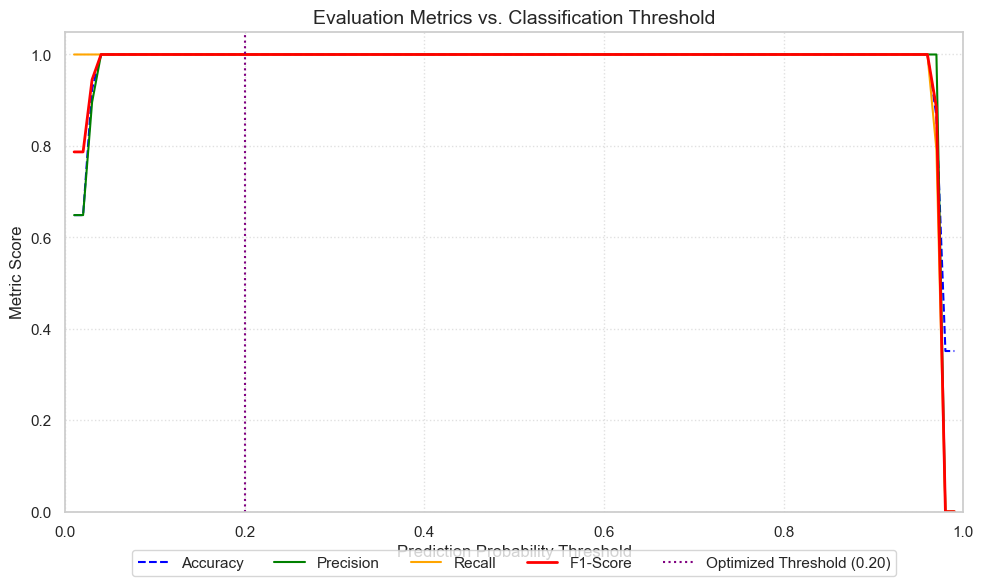

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# 1. Define a range of thresholds from 0.01 to 0.99
thresholds = np.arange(0.01, 1.00, 0.01)

# 2. Initialize lists to store the metrics for each threshold
accuracies = []
precisions = []
recalls = []
f1_scores = []

# 3. Calculate metrics at each threshold setup
for t in thresholds:
    # Convert probabilities to binary predictions based on current threshold
    temp_preds = (y_prob >= t).astype(int)
    
    accuracies.append(accuracy_score(y_test, temp_preds))
    precisions.append(precision_score(y_test, temp_preds, zero_division=0))
    recalls.append(recall_score(y_test, temp_preds, zero_division=0))
    f1_scores.append(f1_score(y_test, temp_preds, zero_division=0))

# 4. Plot the performance curves
plt.figure(figsize=(10, 6))
plt.plot(thresholds, accuracies, label='Accuracy', color='blue', linestyle='--')
plt.plot(thresholds, precisions, label='Precision', color='green')
plt.plot(thresholds, recalls, label='Recall', color='orange')
plt.plot(thresholds, f1_scores, label='F1-Score', color='red', linewidth=2)

# Highlight the optimized threshold you found during training
plt.axvline(x=best_threshold, color='purple', linestyle=':', label=f'Optimized Threshold ({best_threshold:.2f})')

# Customizing the chart aesthetics
plt.title('Evaluation Metrics vs. Classification Threshold', fontsize=14)
plt.xlabel('Prediction Probability Threshold', fontsize=12)
plt.ylabel('Metric Score', fontsize=12)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(0, 1)
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

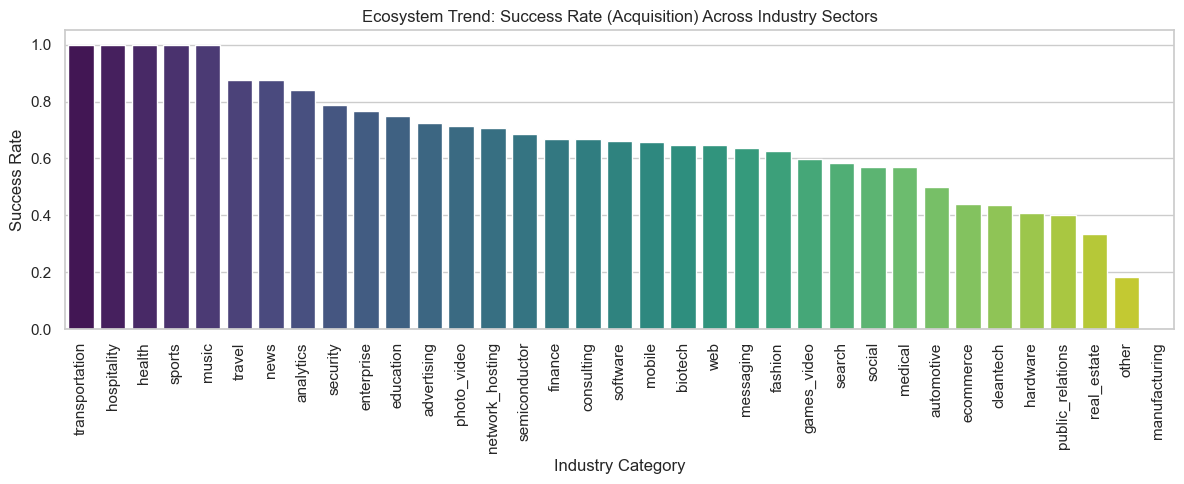

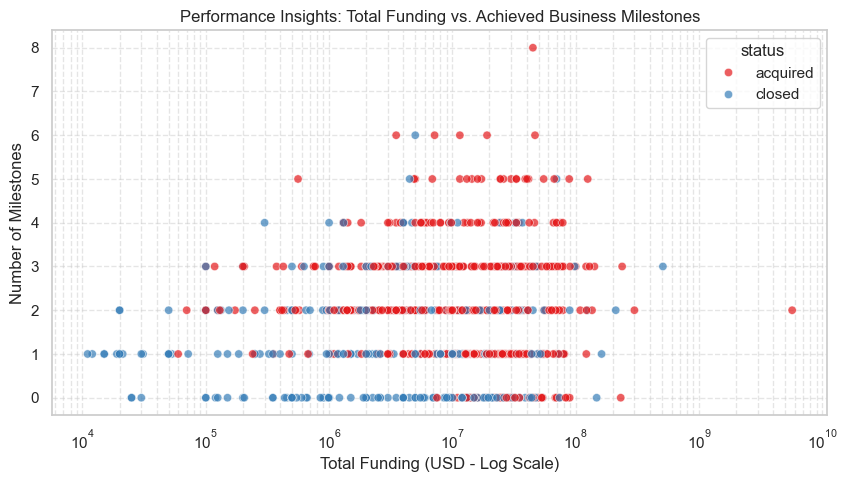

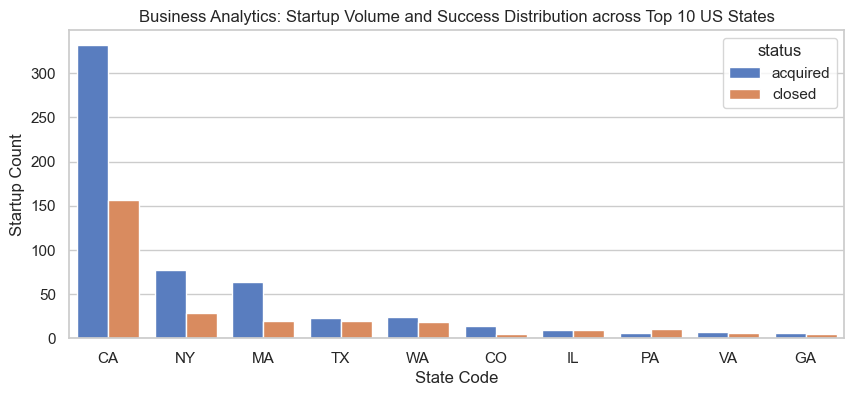

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Secondary Objective 1: Analyze Startup Ecosystem Trends (Category Success Rate)
plt.figure(figsize=(12, 5))
category_success = df.groupby('category_code')['status'].apply(lambda x: (x == 'acquired').mean()).sort_values(ascending=False)
sns.barplot(x=category_success.index, y=category_success.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Ecosystem Trend: Success Rate (Acquisition) Across Industry Sectors")
plt.xlabel("Industry Category")
plt.ylabel("Success Rate")
plt.tight_layout()
plt.show()

# Secondary Objective 2: Startup Performance Insights (Funding vs. Milestones achieved)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='funding_total_usd', y='milestones', hue='status', alpha=0.7, palette="Set1")
plt.xscale('log')
plt.title("Performance Insights: Total Funding vs. Achieved Business Milestones")
plt.xlabel("Total Funding (USD - Log Scale)")
plt.ylabel("Number of Milestones")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

# Secondary Objective 3: Visualize Business Analytics (Geographical Success Distribution)
plt.figure(figsize=(10, 4))
top_states = df['state_code'].value_counts().head(10).index
df_top_states = df[df['state_code'].isin(top_states)]
sns.countplot(data=df_top_states, x='state_code', hue='status', palette="muted", order=top_states)
plt.title("Business Analytics: Startup Volume and Success Distribution across Top 10 US States")
plt.xlabel("State Code")
plt.ylabel("Startup Count")
plt.show()

--- XGBoost Model Performance Metrics ---
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000

--- Initializing Module 7: Explainable AI (SHAP) ---


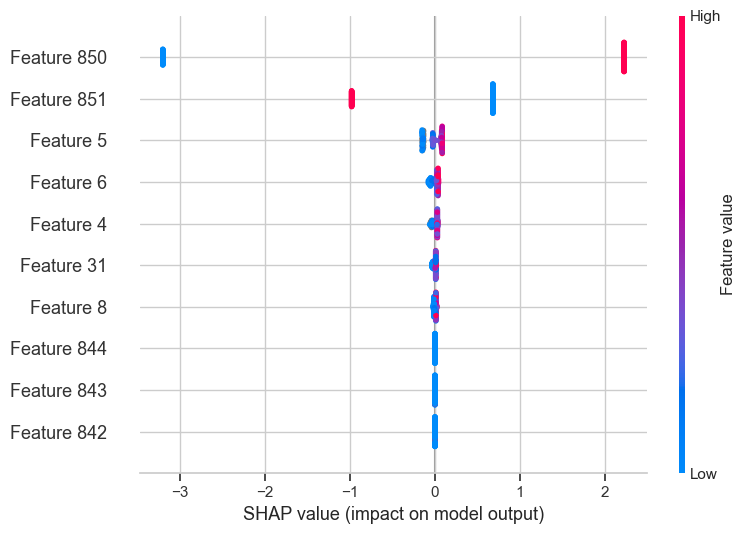

In [51]:
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Make sure your XGBoost model is fitted
# xgb_model.fit(X_train_processed, y_train) # (Run this if not already executed)

# Calculate Validation Metrics (Module 6)
y_pred = xgb_model.predict(X_test_processed)
y_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

print("--- XGBoost Model Performance Metrics ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}\n")

print("--- Initializing Module 7: Explainable AI (SHAP) ---")
# Use standard shap.Explainer which optimizes directly for XGBoost models
explainer = shap.Explainer(xgb_model, X_train_processed)
shap_values = explainer(X_test_processed)

# Plot global feature importance summary using SHAP
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_processed, max_display=10)

In [52]:
def startup_success_score_generator(processed_features, raw_startup_row):
    """
    Generates a startup success score (0-100), maps risk categories, 
    and offers specific business insights.
    """
    # 1. Generate Success Score (Module 8)
    # Reshape input to a single sample vector if necessary
    features_tensor = processed_features.reshape(1, -1)
    predicted_probability = xgb_model.predict_proba(features_tensor)[0][1]
    success_score = round(predicted_probability * 100, 1)
    
    # 2. Risk Classification Mapping
    if 0 <= success_score <= 40:
        risk_category = "High Risk"
    elif 41 <= success_score <= 70:
        risk_category = "Moderate Risk"
    else:
        risk_category = "High Potential"
        
    # 3. Recommendation Rules Logic (Module 9)
    recommendations = []
    
    # Safely extract values from the raw dictionary/series row
    funding = raw_startup_row.get('funding_total_usd', 0)
    milestones = raw_startup_row.get('milestones', 0)
    relationships = raw_startup_row.get('relationships', 0)
    
    if funding < 500000:
        recommendations.append("🚨 Raise additional funding: Your total funding level is lower than optimal benchmark thresholds.")
    if milestones <= 1:
        recommendations.append("🎯 Focus on business milestones: Push product versions or strategic indicators to demonstrate growth traction.")
    if relationships < 3:
        recommendations.append("🤝 Expand market reach: Build key partner networks, advisory relationships, and ecosystem presence.")
    
    if not recommendations:
        recommendations.append("Maintain scale: Continue current customer retention strategies and look toward geographic market expansion.")
        
    # Print clean diagnostic dashboard layout matching expected output structure
    print("="*50)
    print("         STARTUP PREDICTION ANALYTICS PROFILE")
    print("="*50)
    print(f"Success Probability  : {success_score}%")
    print(f"Startup Score        : {int(success_score)}/100")
    print(f"Risk Category        : {risk_category}")
    print("-"*50)
    print("RECOMMENDATIONS ENGINE:")
    for i, rec in enumerate(recommendations, 1):
        print(f" {i}. {rec}")
    print("="*50)

# --- Test Execution on a single validation sample ---
sample_idx = 0
sample_vector = X_test_processed[sample_idx]
sample_raw_data = X_test.iloc[sample_idx].to_dict()

# Generate the dashboard output
startup_success_score_generator(sample_vector, sample_raw_data)

         STARTUP PREDICTION ANALYTICS PROFILE
Success Probability  : 97.5999984741211%
Startup Score        : 97/100
Risk Category        : High Potential
--------------------------------------------------
RECOMMENDATIONS ENGINE:
 1. Maintain scale: Continue current customer retention strategies and look toward geographic market expansion.


In [53]:
import pickle

# Save the trained XGBoost model structure
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

# Save the ColumnTransformer/Encoding pipeline object you used to clean your data 
# (Replace 'preprocessor' with whatever your pipeline variable name is)
with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

print("Saved model artifacts successfully!")

Saved model artifacts successfully!
